In [63]:
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.io
import matplotlib.image as mpimg
from sklearn.decomposition import PCA
from skimage.transform import resize

def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])


In [64]:
mat_contents = scipy.io.loadmat(os.path.join('./','allFaces.mat')) #legge un file di matlab e lo carica in un dizionario python
print(mat_contents.keys())
faces = mat_contents['faces'] #matrice delle immagini delle facce: 2410 facce da 32256 pixel
n = int(mat_contents['n'].item()) #altezza immagine
m = int(mat_contents['m'].item()) #larghezza immagine
nfaces = np.ndarray.flatten(mat_contents['nfaces'])
print(f"righe: {n},colonne: {m}")
print(faces.shape) #(n_pixel, n_facce)

dict_keys(['__header__', '__version__', '__globals__', 'faces', 'n', 'm', 'sub', 'nfaces', 'person'])
righe: 192,colonne: 168
(32256, 2410)


In [65]:
print(nfaces)
print(nfaces.shape) #numero di persone nel dataset

[64 62 64 64 62 64 64 64 64 64 60 59 60 63 62 63 63 64 64 64 64 64 64 64
 64 64 64 64 64 64 64 64 64 64 64 64 64 64]
(38,)


In [66]:
n_face = np.sum(nfaces[:38]) #utilizzo tutte le facce (38 persone)
print(n_face)


2410


In [67]:
trainingFaces = faces[:,:np.sum(n_face)] 
avgFace = np.mean(trainingFaces,axis=1) 

# Trovo le autofacce sui dati mean-subtracted
X = trainingFaces - np.tile(avgFace,(trainingFaces.shape[1],1)).T
U, S, VT = np.linalg.svd(X, full_matrices=0)

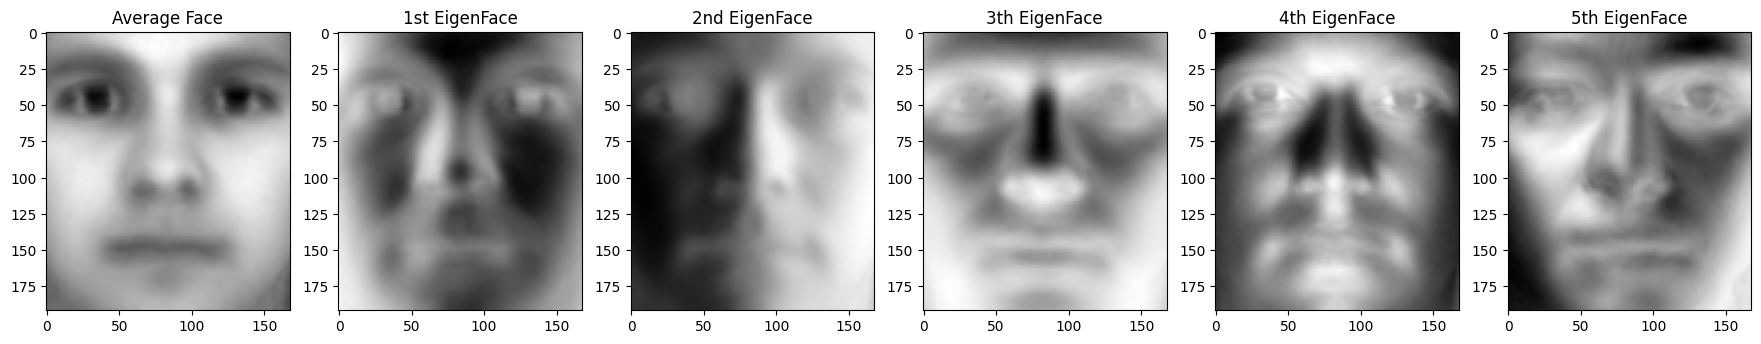

In [68]:
fig = plt.figure(figsize = (22,6))

ax1 = fig.add_subplot(161)
img_avg = ax1.imshow(np.reshape(avgFace,(m,n)).T, cmap='gray')
ax1.set_title("Average Face")

ax2 = fig.add_subplot(162)
img_u1 = ax2.imshow(U[:, 0].reshape(m, n).T, cmap='gray')
ax2.set_title("1st EigenFace")

ax3 = fig.add_subplot(163)
img_u2 = ax3.imshow(U[:, 1].reshape(m, n).T, cmap='gray')
ax3.set_title("2nd EigenFace")

ax4 = fig.add_subplot(164)
img_u3 = ax4.imshow(U[:, 2].reshape(m, n).T, cmap='gray')
ax4.set_title("3th EigenFace")

ax5 = fig.add_subplot(165)
img_u4 = ax5.imshow(U[:, 3].reshape(m, n).T, cmap='gray')
ax5.set_title("4th EigenFace")

ax6 = fig.add_subplot(166)
img_u5 = ax6.imshow(U[:, 4].reshape(m, n).T, cmap='gray')
ax6.set_title("5th EigenFace")
img_u5.set_cmap('gray')

plt.show()

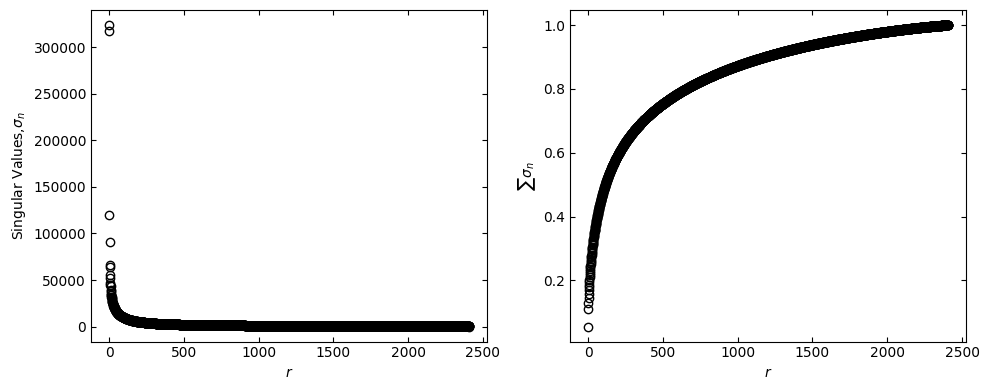

In [69]:
fig, axes = plt.subplots(1, 2, figsize = (10,4))

ax = axes[0]
ax.plot(S, marker = 'o', ls='', markerfacecolor = 'none', markeredgecolor='k')
ax.set_xlabel(r'$r$')
ax.set_ylabel('Singular Values,' + r'$\sigma_n$')
ax.xaxis.set_tick_params(direction='in', which='both')
ax.yaxis.set_tick_params(direction='in', which='both')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

ax = axes[1]
ax.plot(np.cumsum(S)/np.sum(S), marker = 'o', ls='', markerfacecolor = 'none', markeredgecolor='k')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\sum\sigma_n$')
ax.xaxis.set_tick_params(direction='in', which='both')
ax.yaxis.set_tick_params(direction='in', which='both')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

plt.tight_layout()

plt.show()

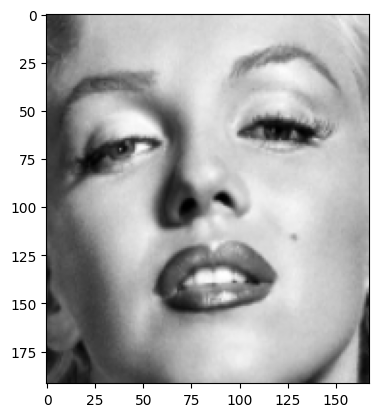

In [70]:
img = mpimg.imread('Marilyn.jpg')
img_gray = rgb2gray(img)

# resize correttamente
X = resize(img_gray, (n, m), anti_aliasing=True)

# match intensity scale
X = X * 255.0

# flatten in column-major, come 'faces'
img_vector = X.T.flatten()
plt.imshow(X, cmap='gray')  

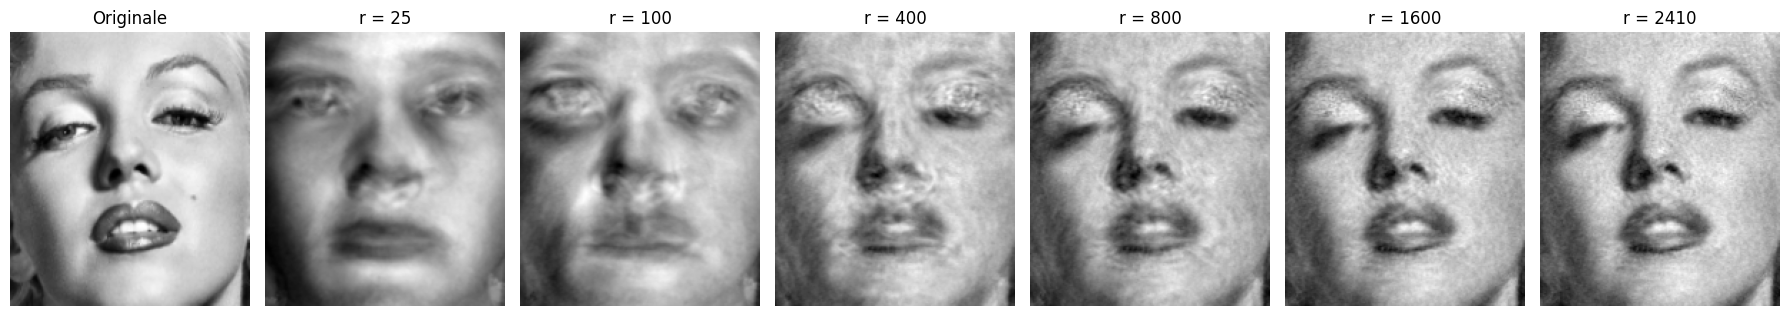

In [71]:
testFaceMS = img_vector - avgFace

testFaceMS = img_vector - avgFace
r_list = [25,100, 400, 800, 1600, n_face]

mse_history_mari = []
    
fig, axes = plt.subplots(1, len(r_list)+1, figsize=(18, 5))  # +1 per originale

# Plotto prima l'immagine originale
axes[0].imshow(np.reshape(img_vector, (m, n)).T, cmap='gray')
axes[0].set_title('Originale')
axes[0].axis('off')

# Poi ricostruzioni
for i, r in enumerate(r_list):
    coeff = U[:, :r].T @ testFaceMS
    reconFace = avgFace + U[:, :r] @ coeff

    mse = np.mean((img_vector - reconFace)**2)
    mse_history_mari.append(mse)

    axes[i+1].imshow(np.reshape(reconFace, (m, n)).T, cmap='gray')
    axes[i+1].set_title('r = ' + str(r))
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

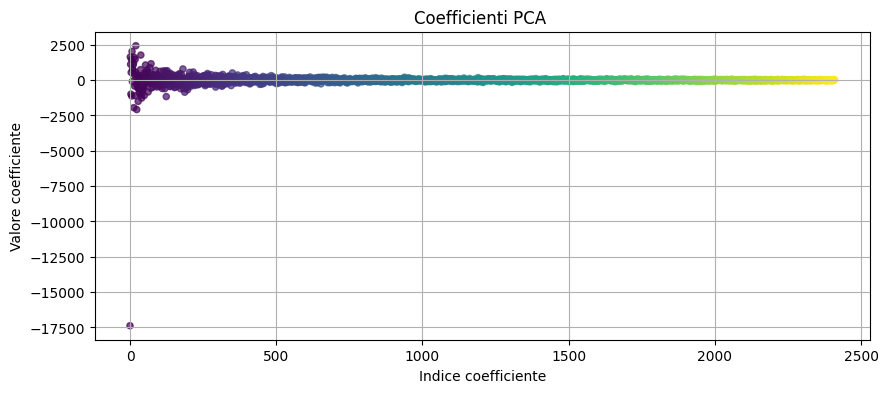

In [72]:
coeff = U[:, :r].T @ testFaceMS

plt.figure(figsize=(10,4))
indices = np.arange(len(coeff))
# Scatter con mappa colori
sc = plt.scatter(indices, coeff, c=indices, alpha=0.7, s=20)

plt.title('Coefficienti PCA ')
plt.xlabel('Indice coefficiente')
plt.ylabel('Valore coefficiente')
plt.grid(True)

plt.show()

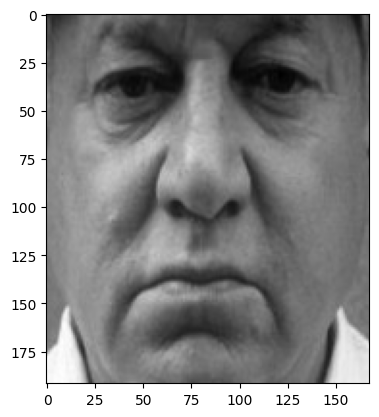

In [80]:
img = mpimg.imread('Fantozzi.jpg')
img_gray = rgb2gray(img)

# resize correttamente
X = resize(img_gray, (n, m), anti_aliasing=True)

# match intensity scale (importantissimo!)
X = X * 255.0

# flatten in column-major, come 'faces'
img_vector = X.T.flatten()
plt.imshow(X, cmap='gray')  

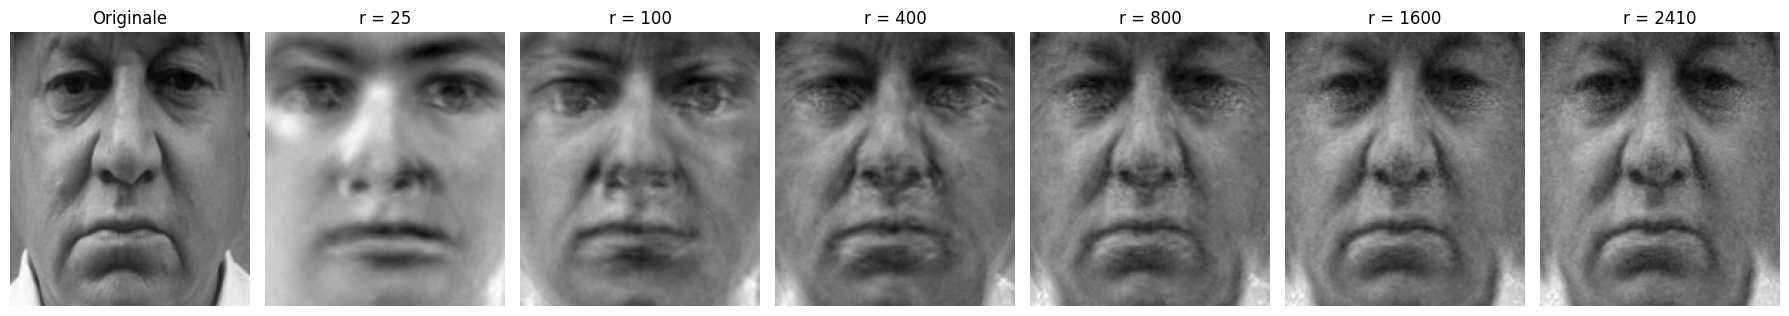

In [81]:
testFaceMS = img_vector - avgFace
r_list = [25,100, 400, 800, 1600, n_face]

mse_history_fant = []
    
fig, axes = plt.subplots(1, len(r_list)+1, figsize=(18, 5))  # +1 per originale

# Plotto prima l'immagine originale
axes[0].imshow(np.reshape(img_vector, (m, n)).T, cmap='gray')
axes[0].set_title('Originale')
axes[0].axis('off')

# Poi ricostruzioni
for i, r in enumerate(r_list):
    coeff = U[:, :r].T @ testFaceMS
    reconFace = avgFace + U[:, :r] @ coeff

    mse = np.mean((img_vector - reconFace)**2)
    mse_history_fant.append(mse)

    axes[i+1].imshow(np.reshape(reconFace, (m, n)).T, cmap='gray')
    axes[i+1].set_title('r = ' + str(r))
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

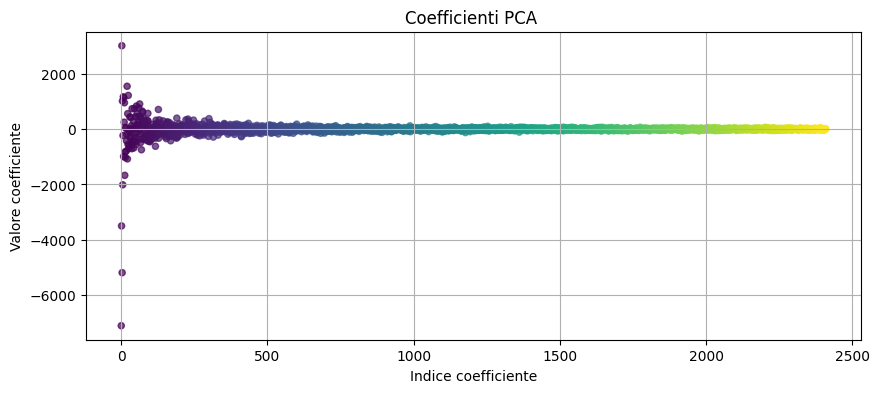

In [82]:
coeff = U[:, :r].T @ testFaceMS

plt.figure(figsize=(10,4))
indices = np.arange(len(coeff))
# Scatter con mappa colori
sc = plt.scatter(indices, coeff, c=indices, alpha=0.7, s=20)

plt.title('Coefficienti PCA ')
plt.xlabel('Indice coefficiente')
plt.ylabel('Valore coefficiente')
plt.grid(True)

plt.show()

(32256,)


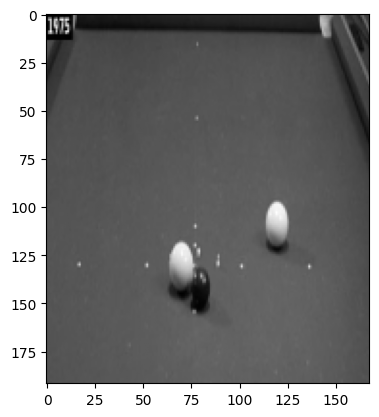

In [76]:
img = mpimg.imread('biliardo.jpg')
img_gray = rgb2gray(img)

# resize correttamente
X = resize(img_gray, (n, m), anti_aliasing=True)

# match intensity scale 
X = X * 255.0

# flatten in column-major, come 'faces'
img_vector = X.T.flatten()
print(img_vector.shape)

plt.imshow((img_vector.reshape(m,n)).T, cmap=plt.get_cmap('gray'))
plt.show()


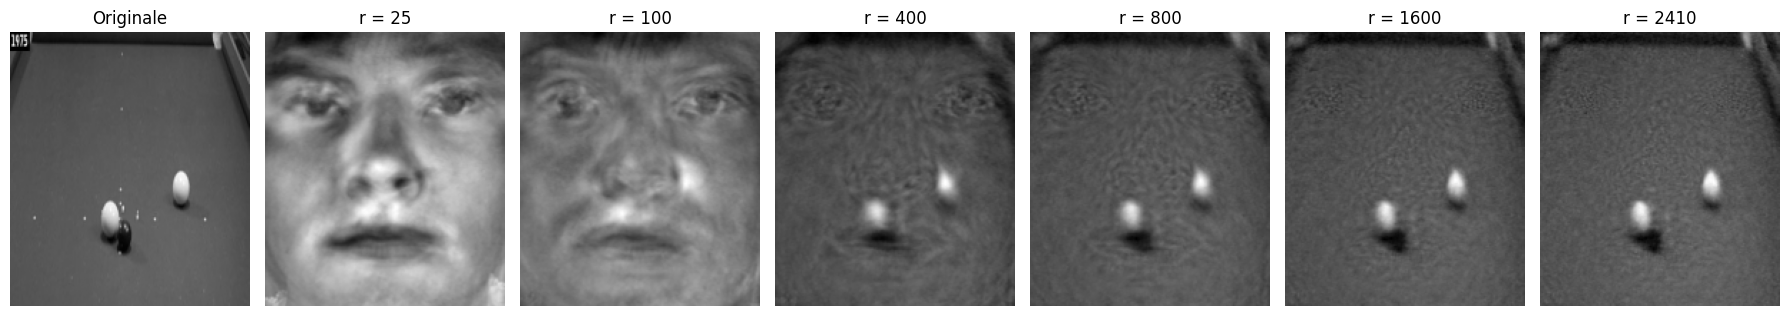

In [77]:
testFaceMS = img_vector - avgFace

testFaceMS = img_vector - avgFace
r_list = [25,100, 400, 800, 1600, n_face]

mse_history_obj = []
    
fig, axes = plt.subplots(1, len(r_list)+1, figsize=(18, 5))  # +1 per originale

# Plotto prima l'immagine originale
axes[0].imshow(np.reshape(img_vector, (m, n)).T, cmap='gray')
axes[0].set_title('Originale')
axes[0].axis('off')

# Poi ricostruzioni
for i, r in enumerate(r_list):
    coeff = U[:, :r].T @ testFaceMS
    reconFace = avgFace + U[:, :r] @ coeff

    mse = np.mean((img_vector - reconFace)**2)
    mse_history_obj.append(mse)

    axes[i+1].imshow(np.reshape(reconFace, (m, n)).T, cmap='gray')
    axes[i+1].set_title('r = ' + str(r))
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

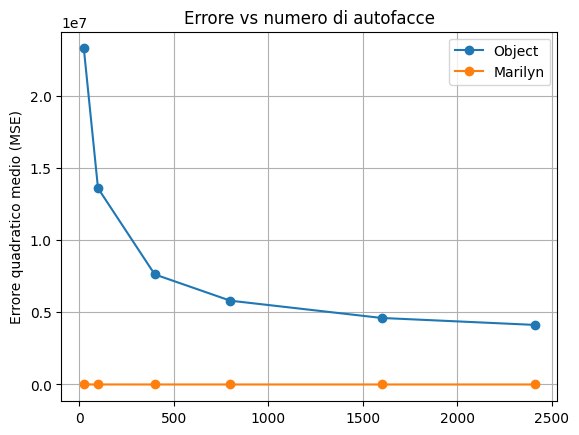

In [78]:
# Plot dell'errore in funzione di r
plt.figure()
plt.plot(r_list, mse_history_obj, marker='o', label='Object')
plt.plot(r_list, mse_history_mari, marker='o', label='Marilyn')
plt.ylabel('Errore quadratico medio (MSE)')
plt.title('Errore vs numero di autofacce')
plt.legend()
plt.grid(True)
plt.show()

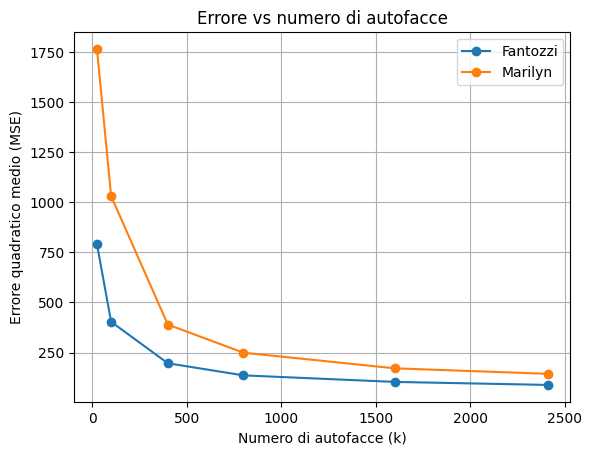

In [79]:
plt.plot(r_list, mse_history_fant, marker='o', label='Fantozzi')
plt.plot(r_list, mse_history_mari, marker='o', label='Marilyn')
plt.xlabel('Numero di autofacce (k)')
plt.ylabel('Errore quadratico medio (MSE)')
plt.title('Errore vs numero di autofacce')
plt.legend()
plt.grid(True)
plt.show()